<a href="https://colab.research.google.com/github/Thalapathi26/AI_ML/blob/main/KNN_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv('/content/drug200.csv')
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
BP,0
Cholesterol,0
Na_to_K,0
Drug,0


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Sex']=le.fit_transform(df['Sex'])
df['BP']=le.fit_transform(df['BP'])
df['Cholesterol']=le.fit_transform(df['Cholesterol'])
df['Drug']=le.fit_transform(df['Drug'])
df


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0
...,...,...,...,...,...,...
195,56,0,1,0,11.567,3
196,16,1,1,0,12.006,3
197,52,1,2,0,9.894,4
198,23,1,2,1,14.020,4


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
df[['Age','Na_to_K']]=sc.fit_transform(df[['Age','Na_to_K']])

In [ ]:
x=df.drop('Drug',axis=1)
y=df['Drug']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,-1.291591,0,0,0,1.286522,0
1,0.162699,1,1,0,-0.415145,3
2,0.162699,1,1,0,-0.828558,3
3,-0.988614,0,2,0,-1.149963,4
4,1.011034,0,1,0,0.271794,0
...,...,...,...,...,...,...
195,0.708057,0,1,0,-0.626917,3
196,-1.715759,1,1,0,-0.565995,3
197,0.465676,1,2,0,-0.859089,4
198,-1.291591,1,2,1,-0.286500,4


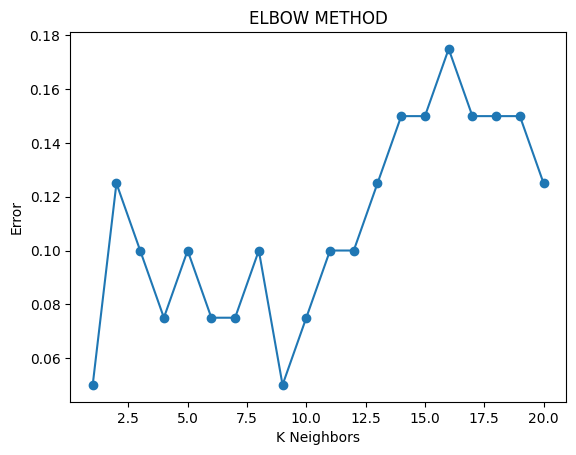

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error=[]

for i in range(1,21):
  knn=KNeighborsClassifier(n_neighbors=i)
  knn.fit(x_train,y_train)
  pred_i=knn.predict(x_test)
  error.append(np.mean(pred_i!=y_test))

plt.plot(range(1,21),error, marker='o')
plt.xlabel('K Neighbors')
plt.ylabel('Error')
plt.title('ELBOW METHOD')
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=9)
knn.fit(x_train,y_train)

KNeighborsClassifier(n_neighbors=9)

In [ ]:
y_pred=knn.predict(x_test)
y_pred

array([4, 0, 4, 3, 0, 0, 0, 4, 1, 4, 1, 4, 0, 1, 2, 0, 2, 4, 4, 0, 2, 4,
       4, 0, 0, 0, 3, 4, 0, 4, 0, 3, 4, 0, 1, 0, 4, 1, 0, 1])

In [ ]:
from sklearn.metrics import confusion_matrix,accuracy_score
ac=accuracy_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
cm
ac

0.95